In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED, DenHaanMarcet
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression import TemplateConfig, PySRParams, ModelParametrizer

from sympy import Matrix, Float, preorder_traversal
from warnings import catch_warnings, simplefilter

from numpy import log
import numpy as np

from scipy.linalg import cholesky, solve_triangular
from scipy.stats import t
from sklearn.metrics import r2_score

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import cProfile

_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

def walk_round(x, n=3):
    for atom in preorder_traversal(x):
        if isinstance(atom, Float):
            x = x.subs(atom, round(atom, n))
    return x

def OLS(y, X, intercept=True):
    if intercept:
        X = np.column_stack([np.ones(X.shape[0]), X])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fit = X @ beta
    resid = y - fit
    r2 = r2_score(y, fit)
    return beta, fit, resid, r2

def t_test_significance(resid, X, beta, intercept=True):
    if intercept:
        X = np.column_stack([np.ones(X.shape[0]), X])
    n, k = X.shape
    sigma2 = np.sum(resid**2) / (n - k)
    var_beta = sigma2 * np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(np.diag(var_beta))
    t_stats = beta / se_beta
    p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=n - k))
    return t_stats, p_values

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# Load reference model
parser = ModelParser("../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [3]:
# Load Misspecified DGP
parser_dgp = ModelParser("../MODELS/misspec_test/misspec.yaml")
config_dgp, kalman_dgp = parser_dgp.get_all()
solver_dgp = DSGESolver(config_dgp, kalman_dgp)
comp_dgp = solver_dgp.compile(
    n_state=3,
    n_exog=3,
)
sol_dgp = solver_dgp.solve(
    comp_dgp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [4]:
T = 200
gz = lambda seed: Shock(T+1, "norm", multivar=True, seed=seed).shock_generator()
r = lambda seed: Shock(T+1, "norm", multivar=False, seed=seed).shock_generator()

sim_dgp = sol_dgp.sim(
    T=T+1,
    shocks={"g,z": gz(0), "r": r(1)},
    observables=True,
)

In [5]:
# Use DGP observables as kalman filter targets in reference model
obs = np.column_stack([sim_dgp["OutGap"], sim_dgp["Infl"], sim_dgp["Rate"]])[1:, :]
kf = sol.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
)

N, n_obs = kf.innov.shape
std_innov = np.empty_like(kf.innov)

for t in range(N):
    S_t = 0.5 * (kf.S[t] + kf.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov[t] = solve_triangular(L_t, kf.innov[t], lower=True)

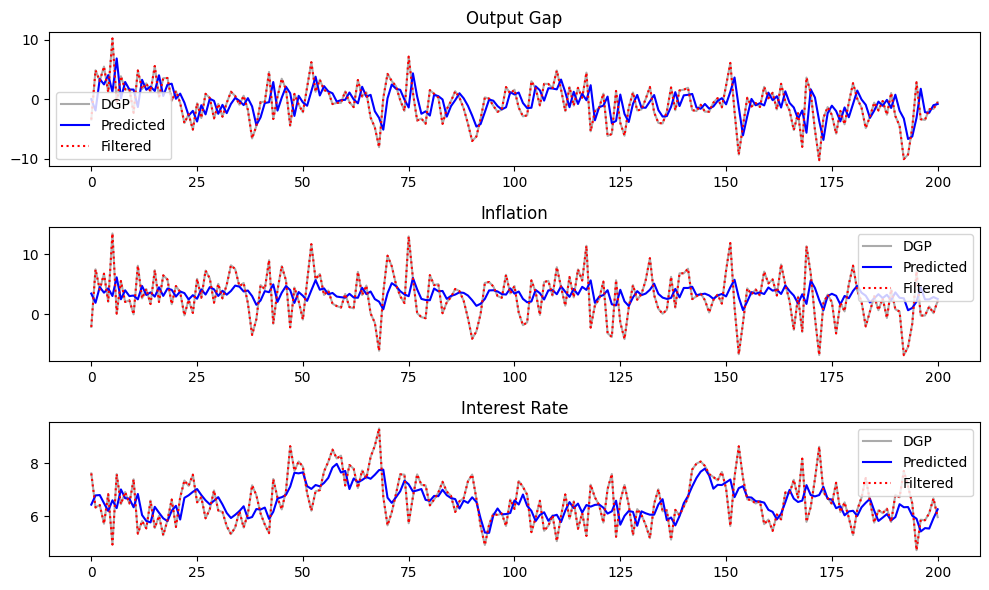

In [6]:
# Plot Filter Outputs
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)
ax[0].plot(range(T+1), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T+1), kf.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T+1), kf.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T+1), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T+1), kf.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T+1), kf.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T+1), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T+1), kf.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T+1), kf.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

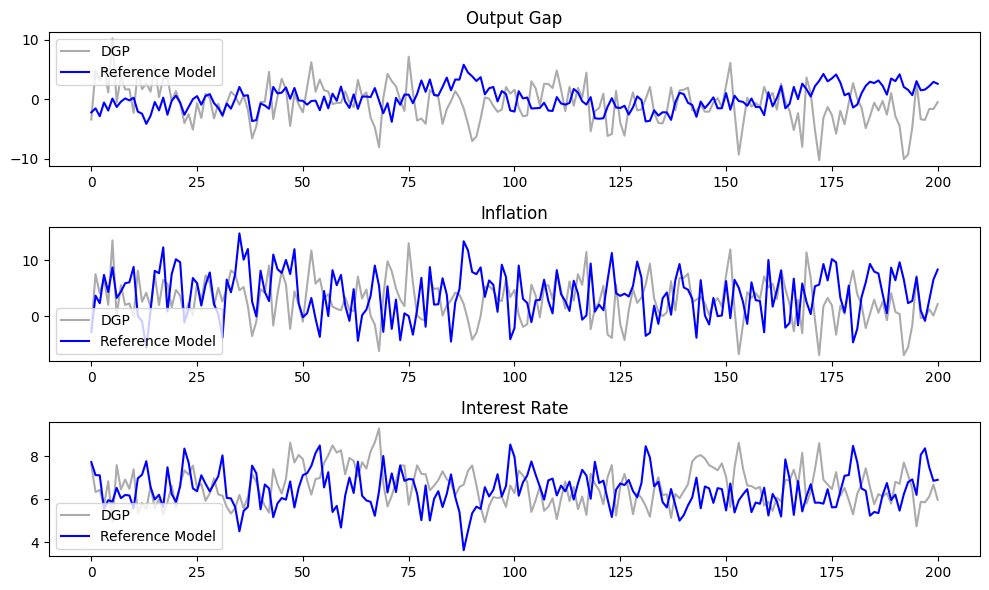

In [7]:
# Simulation against DGP
sim_ref = sol.sim(
    T=T+1,
    shocks={"g,z": gz(2), "r": r(3)},
    observables=True,
)

ref = np.column_stack([sim_ref["OutGap"], sim_ref["Infl"], sim_ref["Rate"]])[1:, :]

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T+1), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T+1), ref[:, 0], label="Reference Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T+1), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T+1), ref[:, 1], label="Reference Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T+1), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T+1), ref[:, 2], label="Reference Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

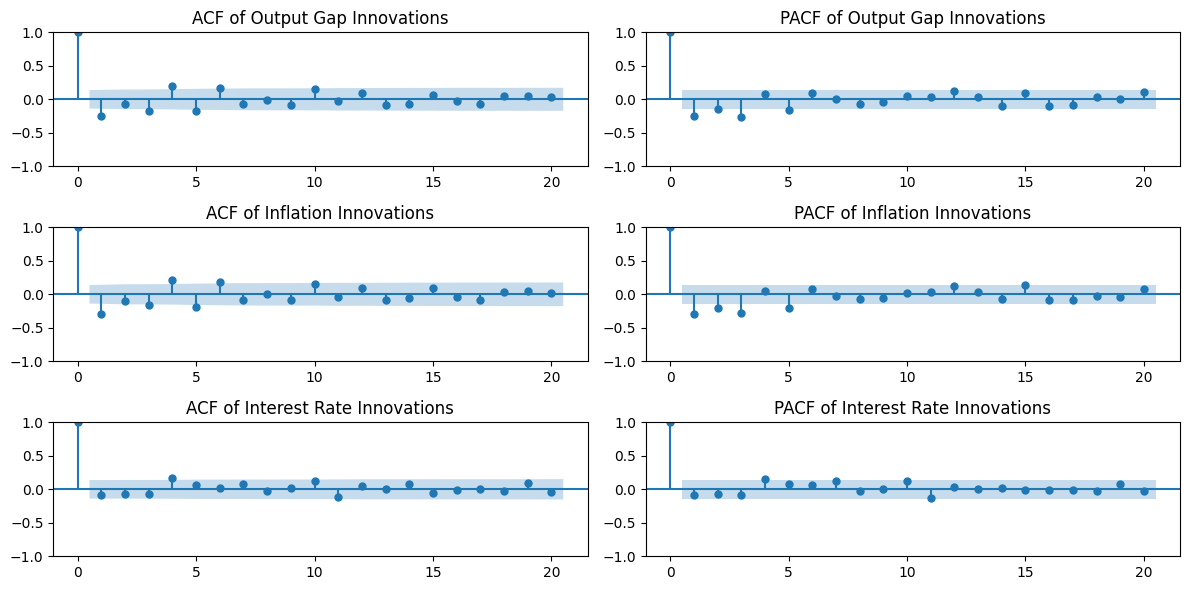

Ljung-Box test for Output Gap Innovations:
    LB Stat=57.08
    p-value=0.0000

Ljung-Box test for Inflation Innovations:
    LB Stat=65.31
    p-value=0.0000

Ljung-Box test for Interest Rate Innovations:
    LB Stat=22.73
    p-value=0.3022



In [9]:
# Plot AFC/PACF of kalman innovations to see if the misspecification appears in the form of serial correlation

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov[:, 0], ax=ax[0, 0], lags=20)
plot_pacf(std_innov[:, 0], ax=ax[0, 1], lags=20)
ax[0, 0].set_title("ACF of Output Gap Innovations")
ax[0, 1].set_title("PACF of Output Gap Innovations")

plot_acf(std_innov[:, 1], ax=ax[1, 0], lags=20)
plot_pacf(std_innov[:, 1], ax=ax[1, 1], lags=20)
ax[1, 0].set_title("ACF of Inflation Innovations")
ax[1, 1].set_title("PACF of Inflation Innovations")

plot_acf(std_innov[:, 2], ax=ax[2, 0], lags=20)
plot_pacf(std_innov[:, 2], ax=ax[2, 1], lags=20)
ax[2, 0].set_title("ACF of Interest Rate Innovations")
ax[2, 1].set_title("PACF of Interest Rate Innovations")

plt.tight_layout()
plt.show()
# Apply Ljung-Box test to check for serial correlation in innovations
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = acorr_ljungbox(std_innov[:, i], lags=[20])
    print(
        f"Ljung-Box test for {var} Innovations:\n    LB Stat={test['lb_stat'].iloc[0]:.2f}\n    p-value={test['lb_pvalue'].iloc[0]:.4f}\n"
    )

In [10]:
mu = std_innov.mean(axis=0)
Sigma = np.cov(std_innov, rowvar=False)

print("Mean:", mu)
print("Covariance:\n", Sigma)
print("Off-diagonals:\n", Sigma - np.diag(np.diag(Sigma)))

Mean: [-0.1343977   0.07912969  0.03657385]
Covariance:
 [[ 5.50060554 -5.87086366  1.54886907]
 [-5.87086366  6.78290456 -1.62804898]
 [ 1.54886907 -1.62804898  1.40423561]]
Off-diagonals:
 [[ 0.         -5.87086366  1.54886907]
 [-5.87086366  0.         -1.62804898]
 [ 1.54886907 -1.62804898  0.        ]]


In [11]:
# OLS regression of innovations against predicted states (orthogonalized)
_, _, Pi_orth, r2_Pi_orth = OLS(kf.x_pred[:, 4], kf.x_pred[:, [2, 3]])  # x_pred[:, g, z, r, x]
_, _, x_orth, r2_X_orth = OLS(kf.x_pred[:, 3], kf.x_pred[:, [2, 4]])  # x_pred[:, g, z, r, Pi]
_, _, r_orth, r2_r_orth = OLS(kf.x_pred[:, 2], kf.x_pred[:, [3, 4]])  # x_pred[:, g, z, x, Pi]

print(f"R^2 for Pi orthogonalized: {r2_Pi_orth:.4f}")
print(f"R^2 for x orthogonalized: {r2_X_orth:.4f}")
print(f"R^2 for r orthogonalized: {r2_r_orth:.4f}")

Pi_orth = Pi_orth.reshape(-1, 1)
x_orth = x_orth.reshape(-1, 1)
r_orth = r_orth.reshape(-1, 1)

R^2 for Pi orthogonalized: 0.7348
R^2 for x orthogonalized: 0.7332
R^2 for r orthogonalized: 0.0130


In [12]:
# Regress on measurement predictions
X = np.column_stack([r_orth, x_orth, Pi_orth])

beta_r_ogap, _, resid_r_ogap, _ = OLS(kf.innov[:, 0], X[:, 0].reshape(-1, 1))
t_r_ogap, p_r_ogap = t_test_significance(resid_r_ogap, X[:, 0].reshape(-1, 1), beta_r_ogap)

beta_x_ogap, _, resid_x_ogap, _ = OLS(kf.innov[:, 0], X[:, 1].reshape(-1, 1))
t_x_ogap, p_x_ogap = t_test_significance(resid_x_ogap, X[:, 1].reshape(-1, 1), beta_x_ogap)

beta_Pi_ogap, _, resid_Pi_ogap, _ = OLS(kf.innov[:, 0], X[:, 2].reshape(-1, 1))
t_Pi_ogap, p_Pi_ogap = t_test_significance(resid_Pi_ogap, X[:, 2].reshape(-1, 1), beta_Pi_ogap)

beta_r_infl, _, resid_r_infl, _ = OLS(kf.innov[:, 1], X[:, 0].reshape(-1, 1))
t_r_infl, p_r_infl = t_test_significance(resid_r_infl, X[:, 0].reshape(-1, 1), beta_r_infl)

beta_x_infl, _, resid_x_infl, _ = OLS(kf.innov[:, 1], X[:, 1].reshape(-1, 1))
t_x_infl, p_x_infl = t_test_significance(resid_x_infl, X[:, 1].reshape(-1, 1), beta_x_infl)

beta_Pi_infl, _, resid_Pi_infl, _ = OLS(kf.innov[:, 1], X[:, 2].reshape(-1, 1))
t_Pi_infl, p_Pi_infl = t_test_significance(resid_Pi_infl, X[:, 2].reshape(-1, 1), beta_Pi_infl)


beta_r_rate, _, resid_r_rate, _ = OLS(kf.innov[:, 2], X[:, 0].reshape(-1, 1))
t_r_rate, p_r_rate = t_test_significance(resid_r_rate, X[:, 0].reshape(-1, 1), beta_r_rate)

beta_x_rate, _, resid_x_rate, _ = OLS(kf.innov[:, 2], X[:, 1].reshape(-1, 1))
t_x_rate, p_x_rate = t_test_significance(resid_x_rate, X[:, 1].reshape(-1, 1), beta_x_rate)

beta_Pi_rate, _, resid_Pi_rate, _ = OLS(kf.innov[:, 2], X[:, 2].reshape(-1, 1))
t_Pi_rate, p_Pi_rate = t_test_significance(resid_Pi_rate, X[:, 2].reshape(-1, 1), beta_Pi_rate)

coef_mat = pd.DataFrame(
    {
        "OutGap": [beta_r_ogap[1], beta_x_ogap[1], beta_Pi_ogap[1]],
        "Infl": [beta_r_infl[1], beta_x_infl[1], beta_Pi_infl[1]],
        "Rate": [beta_r_rate[1], beta_x_rate[1], beta_Pi_rate[1]],
    },
    index=["r", "x", "Pi"],
)

t_mat = pd.DataFrame(
    {
        "OutGap": [p_r_ogap[0], p_x_ogap[0], p_Pi_ogap[0]],
        "Infl": [p_r_infl[0], p_x_infl[0], p_Pi_infl[0]],
        "Rate": [p_r_rate[0], p_x_rate[0], p_Pi_rate[0]],
    },
    index=["r", "x", "Pi"],
)

print("OLS Coefficients of Innovations on Predicted States (Orthogonalized):\n")
print(coef_mat.round(3))

print("\nP-values from t-tests on Coefficients:\n")
print(t_mat.round(3))

AttributeError: 'int' object has no attribute 'cdf'

In [ ]:
print(np.var(r_orth), np.var(x_orth), np.var(Pi_orth))
print(np.linalg.norm(r_orth), np.linalg.norm(x_orth), np.linalg.norm(Pi_orth))

0.018173078510538218 1.2132672825367947 0.016847197689660368
1.9112270353409562 15.616232701579973 1.840186603478499


In [ ]:
print(np.corrcoef(Pi_orth.reshape(-1), kf.innov[:,0])[0,1])
print(np.corrcoef(Pi_orth.reshape(-1), kf.innov[:,1])[0,1])
print(np.corrcoef(Pi_orth.reshape(-1), kf.innov[:,2])[0,1])

-0.223604241845431
-0.06479776744472589
0.026232754171810823


In [ ]:
# Innovation Regression Tests
Pi = kf.x_pred[:, 4].reshape(-1, 1)
x = kf.x_pred[:, 3].reshape(-1, 1)
r = kf.x_pred[:, 2].reshape(-1, 1)


def regression_report(y_idx):
    y = kf.innov[:, y_idx]
    beta_Pi_innov_ogap, _, resid_Pi_innov_ogap, r2_Pi_ogap = OLS(y, Pi)
    t_Pi_innov_ogap, p_Pi_innov_ogap = t_test_significance(
        resid_Pi_innov_ogap, Pi, beta_Pi_innov_ogap
    )
    beta_Pi_innov_ogap[1] = beta_Pi_innov_ogap[1] * (np.std(Pi)/np.std(y))

    beta_x_innov_ogap, _, resid_x_innov_ogap, r2_x_ogap = OLS(y, x)
    t_x_innov_ogap, p_x_innov_ogap = t_test_significance(
        resid_x_innov_ogap, x, beta_x_innov_ogap
    )
    beta_x_innov_ogap[1] = beta_x_innov_ogap[1] * (np.std(x)/np.std(y))

    beta_r_innov_ogap, _, resid_r_innov_ogap, r2_r_ogap = OLS(y, r)
    t_r_innov_ogap, p_r_innov_ogap = t_test_significance(
        resid_r_innov_ogap, r, beta_r_innov_ogap
    )
    beta_r_innov_ogap[1] = beta_r_innov_ogap[1] * (np.std(r)/np.std(y))

    ogap_data = pd.DataFrame(
        {
            "Std. Coef": [beta_Pi_innov_ogap[1], beta_x_innov_ogap[1], beta_r_innov_ogap[1]],
            "p-value": [p_Pi_innov_ogap[0], p_x_innov_ogap[0], p_r_innov_ogap[0]],
            "R^2": [r2_Pi_ogap, r2_x_ogap, r2_r_ogap],
        },
        index=["Pi", "x", "r"],
    )
    return ogap_data

def regression_report_orth(y_idx):
    y = kf.innov[:, y_idx]
    beta_Pi_innov_ogap, _, resid_Pi_innov_ogap, r2_Pi_ogap = OLS(y, Pi_orth)
    t_Pi_innov_ogap, p_Pi_innov_ogap = t_test_significance(
        resid_Pi_innov_ogap, Pi_orth, beta_Pi_innov_ogap
    )
    beta_Pi_innov_ogap[1] = beta_Pi_innov_ogap[1] * (np.std(Pi_orth)/np.std(y))

    beta_x_innov_ogap, _, resid_x_innov_ogap, r2_x_ogap = OLS(y, x_orth)
    t_x_innov_ogap, p_x_innov_ogap = t_test_significance(
        resid_x_innov_ogap, x_orth, beta_x_innov_ogap
    )
    beta_x_innov_ogap[1] = beta_x_innov_ogap[1] * (np.std(x_orth)/np.std(y))

    beta_r_innov_ogap, _, resid_r_innov_ogap, r2_r_ogap = OLS(y, r_orth)
    t_r_innov_ogap, p_r_innov_ogap = t_test_significance(
        resid_r_innov_ogap, r_orth, beta_r_innov_ogap
    )
    beta_r_innov_ogap[1] = beta_r_innov_ogap[1] * (np.std(r_orth)/np.std(y))
    
    ogap_data = pd.DataFrame(
        {
            "Std. Coef": [beta_Pi_innov_ogap[1], beta_x_innov_ogap[1], beta_r_innov_ogap[1]],
            "p-value": [p_Pi_innov_ogap[0], p_x_innov_ogap[0], p_r_innov_ogap[0]],
            "R^2": [r2_Pi_ogap, r2_x_ogap, r2_r_ogap],
        },
        index=["Pi", "x", "r"],
    )
    return ogap_data

# Ogap
print("Regression of Output Gap Innovations on Predicted States:\n")
print(regression_report(0))
print("\nRegression of Output Gap Innovations on Predicted States (Orthogonalized):\n")
print(regression_report_orth(0))
print("\n\n")

# Inflation
print("Regression of Inflation Innovations on Predicted States:\n")
print(regression_report(1))
print("\nRegression of Inflation Innovations on Predicted States (Orthogonalized):\n")
print(regression_report_orth(1))
print("\n\n")

# Interest Rate
print("Regression of Interest Rate Innovations on Predicted States:\n")
print(regression_report(2))
print("\nRegression of Interest Rate Innovations on Predicted States (Orthogonalized):\n")
print(regression_report_orth(2))

Regression of Output Gap Innovations on Predicted States:

    Std. Coef   p-value       R^2
Pi  -0.369984  0.122012  0.136888
x   -0.296280  0.061987  0.087782
r    0.051896  0.337546  0.002693

Regression of Output Gap Innovations on Predicted States (Orthogonalized):

    Std. Coef   p-value       R^2
Pi  -0.223604  0.387563  0.049999
x    0.039385  0.399306  0.001551
r    0.009926  0.399648  0.000099



Regression of Inflation Innovations on Predicted States:

    Std. Coef   p-value       R^2
Pi  -0.056934  0.173822  0.003241
x   -0.026814  0.184489  0.000719
r    0.016740  0.195078  0.000280

Regression of Inflation Innovations on Predicted States (Orthogonalized):

    Std. Coef   p-value       R^2
Pi  -0.064798  0.201693  0.004199
x    0.042184  0.202238  0.001780
r    0.009376  0.202619  0.000088



Regression of Interest Rate Innovations on Predicted States:

    Std. Coef   p-value       R^2
Pi   0.067026  0.090835  0.004492
x    0.063492  0.079144  0.004031
r    0.015198  0